## Analyzing Covariance Matrices

Here we analyze the covariance for shear, which is computed in TXPipe, and for counts, computed in TJPCov but corrected by the CLPipe repository due to the lack of selection function in TJPCov.

In [1]:
import sys
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sacc

## Shear Covariance

tan_bootstrap covariance:


,0,1,2,3,4,5,6
0,1.468265e+25,3.243046e+24,4.369554e+23,-1.825545e+24,8.052502e+23,8.287625e+23,-7.865959e+22
1,3.243046e+24,7.415982e+24,8.809877e+23,-6.214865e+22,8.331121e+23,-7.394779e+23,9.159163e+23
2,4.369554e+23,8.809877e+23,6.330385e+24,1.750214e+24,6.480800e+23,1.429757e+22,6.909858e+23
3,-1.825545e+24,-6.214865e+22,1.750214e+24,4.908898e+24,2.604042e+23,5.145976e+23,1.200449e+24
4,8.052502e+23,8.331121e+23,6.480800e+23,2.604042e+23,3.831833e+24,3.621562e+23,2.452948e+23
5,8.287625e+23,-7.394779e+23,1.429757e+22,5.145976e+23,3.621562e+23,2.977797e+24,6.466809e+23
6,-7.865959e+22,9.159163e+23,6.909858e+23,1.200449e+24,2.452948e+23,6.466809e+23,2.124599e+24


cross_bootstrap covariance:


,0,1,2,3,4,5,6
0,9.059135e+24,5.465468e+23,-3.130766e+23,-6.830148e+23,6.239837e+23,-3.906776e+23,3.216961e+23
1,5.465468e+23,1.034052e+25,7.072872e+23,7.442645e+23,-2.047827e+23,-6.620526e+23,1.169666e+23
2,-3.130766e+23,7.072872e+23,4.096010e+24,-3.411841e+23,3.298708e+23,-4.012254e+23,-4.013069e+23
3,-6.830148e+23,7.442645e+23,-3.411841e+23,3.396878e+24,6.413951e+23,3.042173e+22,1.878435e+23
4,6.239837e+23,-2.047827e+23,3.298708e+23,6.413951e+23,2.848972e+24,3.760532e+23,2.633079e+23
5,-3.906776e+23,-6.620526e+23,-4.012254e+23,3.042173e+22,3.760532e+23,1.553865e+24,1.050472e+23
6,3.216961e+23,1.169666e+23,-4.013069e+23,1.878435e+23,2.633079e+23,1.050472e+23,1.211220e+24


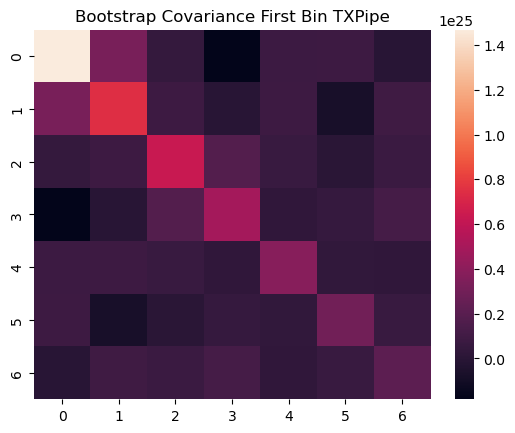

[np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


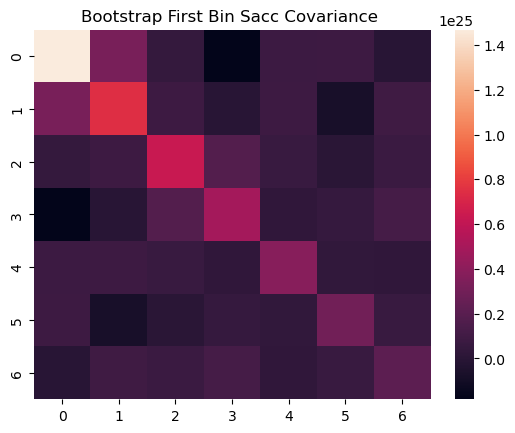

In [2]:
cluster_profiles = "/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-full-2026/cluster_profiles.pkl"
data = pkl.load(open(cluster_profiles, "rb"))

cov_data = data["bin_zbin_0_richbin_0"]["clmm_cluster_ensemble"].cov

tan_bs_df = pd.DataFrame(cov_data['tan_bs'])
cross_bs_df = pd.DataFrame(cov_data['cross_bs'])

print("tan_bootstrap covariance:")
display(tan_bs_df)  # Jupyter-friendly table

print("cross_bootstrap covariance:")
display(cross_bs_df)

sns.heatmap(cov_data['tan_bs'], annot=False, fmt=".2e")
plt.title("Bootstrap Covariance First Bin TXPipe")
plt.show()


t = sacc.Sacc.load_fits("/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-full-2026/cluster_sacc_catalog.sacc")
idx_cov_ds_00 = []
for i in range(0,7):
    trac = ('cosmodc2_redmapper', 'bin_rich_0', 'bin_z_0', f'radius_{i}')
    idx_cov_ds_00.append(t.indices(tracers=trac, data_type=sacc.data_types.standard_types.cluster_delta_sigma)[0])
print(idx_cov_ds_00)
cov_ds = t.covariance.get_block(indices=idx_cov_ds_00)
sns.heatmap(cov_ds, annot=False, fmt=".2e")
plt.title("Bootstrap First Bin Sacc Covariance ")
plt.show()

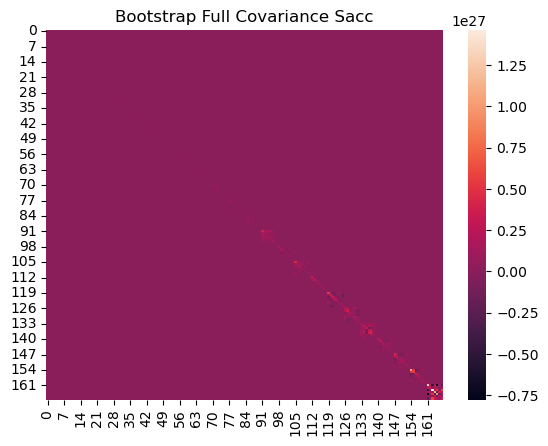

In [3]:
idx_cov_ds = t.indices(data_type=sacc.data_types.standard_types.cluster_delta_sigma)
cov_ds = t.covariance.get_block(indices=idx_cov_ds)
sns.heatmap(cov_ds, annot=False, fmt=".2e")
plt.title("Bootstrap Full Covariance Sacc")
plt.show()


## Cluster Counts Covariance

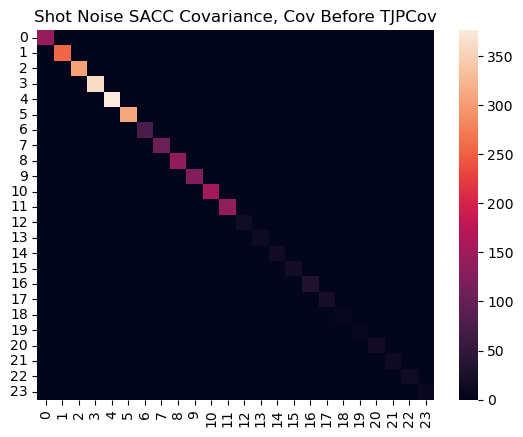

Text(0.5, 1.0, 'Final SN + SCC SACC Covariance')

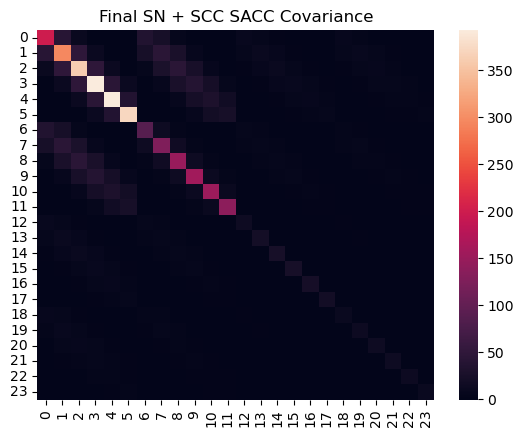

In [4]:
t = sacc.Sacc.load_fits("/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-full-2026/cluster_sacc_catalog.sacc")
tracer_comb = (("cosmodc2_redmapper","bin_z_1", "bin_rich_0"))
data_type = sacc.standard_types.cluster_counts
idx = t.indices(data_type=data_type)
cov_counts = t.covariance.get_block(idx)
sns.heatmap(cov_counts, annot=False, fmt=".2e", label="Shot Noise")
plt.title("Shot Noise SACC Covariance, Cov Before TJPCov")
plt.show()
t2 = sacc.Sacc.load_fits("../../data/cosmodc2_redmapper/sacc/lensing_mor_cov.sacc")
tracer_comb2 = (("cosmodc2_redmapper","bin_z_1", "bin_rich_0"))
data_type = sacc.standard_types.cluster_counts
idx = t2.indices(data_type=data_type)
cov_counts2 = t2.covariance.get_block(idx)

sns.heatmap(cov_counts2, annot=False, fmt=".2e", label="SCC")
plt.title("Final SN + SCC SACC Covariance")


## SSC versus Shot Noise theoretical Covariance

Here we plot both contributions to the theoretical covariance.

Theoretical Counts [140.7720111  219.04111668 281.65848364 320.44567741 333.91567375
 325.16331792  67.88845914 101.88630175 126.02046083 137.60117092
 137.35754454 127.94940587  12.74923501  18.27749675  21.51282757
  22.27794163  21.02827156  18.47327411   8.59882281  11.79077878
  13.23224753  13.03122211  11.67149112   9.71125271]


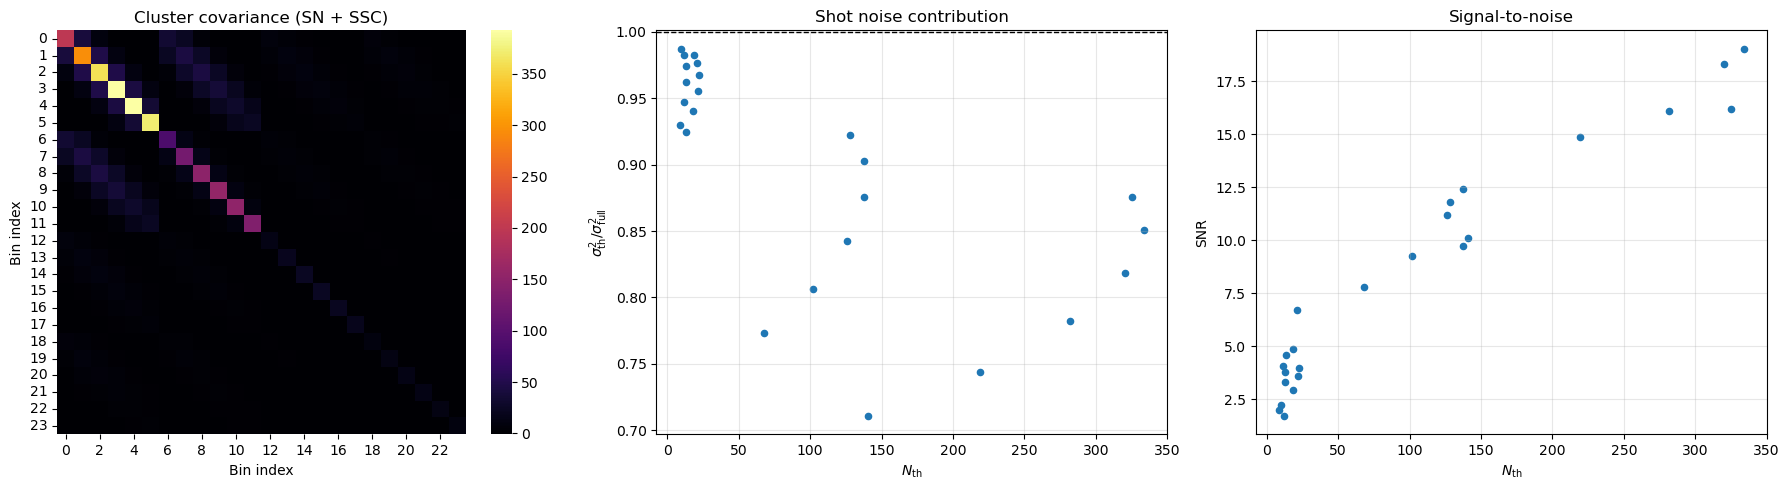

SNR: [10.0902953  14.85819726 16.07084099 18.2945102  19.0326828  16.18732938
  7.78957454  9.25310262 11.20415653  9.73166014 12.40574935 11.80068008
  3.77028692  2.94852061  3.58205894  3.95886578  6.67977565  4.84219613
  1.97315709  1.70043486  4.58434367  3.28053634  4.06137812  2.23193217], Diag Cov: [198.0473046  294.54260356 360.18238606 391.53948734 392.35815255
 371.4999675   87.82501754 126.32576042 149.51432306 157.16136561
 152.10267678 138.74442043  13.78819029  19.43919913  22.52331901
  23.03380292  21.53771544  18.80848591   9.24653834  12.45037704
  13.75129214  13.38051366  11.88253826   9.83635276]


In [5]:
data_type = sacc.standard_types.cluster_counts

# =========================
# Load SACC files
# =========================
t_data = sacc.Sacc.load_fits(
    "/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-full-2026/cluster_sacc_catalog.sacc"
)

t_full = sacc.Sacc.load_fits(
    "../../data/cosmodc2_redmapper/sacc/full_both_cov.sacc"
)

t_ssc = sacc.Sacc.load_fits(
    "../../data/cosmodc2_redmapper/sacc/full_both_cov_SSC.sacc"
)

t_gauss = sacc.Sacc.load_fits(
    "../../data/cosmodc2_redmapper/sacc/full_both_cov_gauss.sacc"
)



# =========================
# Indices
# =========================
idx = t_full.indices(data_type=data_type)
idx_ssc = t_ssc.indices(data_type=data_type)
idx_gauss = t_gauss.indices(data_type=data_type)

# =========================
# Covariances
# =========================
cov_counts = t_full.covariance.get_block(idx)   # FULL = SN + SSC
cov_ssc = t_ssc.covariance.get_block(idx_ssc)
cov_gauss = t_gauss.covariance.get_block(idx_gauss)

# =========================
# Counts data
# =========================
counts = np.array([
    p.value for p in t_full.get_data_points(data_type=data_type)
])
# =========================
# Derived quantities
# =========================
var_full = np.diag(cov_counts)
var_ssc = np.diag(cov_ssc)
counts_tjpcov = np.diag(cov_gauss)
ssc_contribution = var_ssc / counts_tjpcov**2
#################
## Since we do not have an individual file with the theoretical counts from the corrected version in CLPCovariance, we need this computation.##
################
counts_theo = (-1.0 + np.sqrt(1.0 + 4* ssc_contribution * var_full)) / (2.0 * ssc_contribution)

snr = counts / np.sqrt(var_full)
print(f"Theoretical Counts {counts_theo}")
# =========================
# FIGURE (3 panels horizontal)
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------
# (1) FULL covariance (heatmap)
# -------------------------
sns.heatmap(
    cov_counts,
    ax=axes[0],
    annot=False,
    fmt=".2e",
    cmap="inferno",
    cbar=True
)
axes[0].set_title("Cluster covariance (SN + SSC)")
axes[0].set_xlabel("Bin index")
axes[0].set_ylabel("Bin index")

# -------------------------
# (2) variance comparison
# -------------------------
axes[1].scatter(counts_theo, counts_theo / var_full, s=20)

axes[1].axhline(1.0, ls="--", c="black", lw=1)

axes[1].set_title("Shot noise contribution")
axes[1].set_xlabel(r"$N_{\mathrm{th}}$")
axes[1].set_ylabel(r"$\sigma^2_{\mathrm{th}} / \sigma^2_{\mathrm{full}}$")
axes[1].grid(alpha=0.3)

# -------------------------
# (3) SNR
# -------------------------
axes[2].scatter(counts_theo, snr, s=20)

axes[2].set_title("Signal-to-noise")
axes[2].set_xlabel(r"$N_{\mathrm{th}}$")
axes[2].set_ylabel("SNR")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./figures/counts_covariance.pdf")
plt.show()
print(f"SNR: {snr}, Diag Cov: {var_full}")